In [8]:
import os
import pandas as pd
import numpy as np
import torch
import logging
import hashlib
import tempfile
import zipfile
import requests
import matplotlib.pyplot as plt
from numpy import concatenate, full
from tqdm import tqdm
from fnn.microns.__init__ import scan
from fnn.microns.build import network
from fnn.microns.load import params, units, unit_ids


In [ ]:
 #for each sigma in [.01,.05,.10,.20,.30], multiply by 256
    # for image in images (by images we mean frame variable as defined below, should be 90 constant frames, each image has 90 frames)
        # for each noise each time we add noise (implement with another for loop, we need 1000 iterations(at first do 100, 200)), 
            #    make sure in range (0,256)
            # for each scan
                # collect prediction output
                # concat. outputs for different scans
            # concat response outputs, collect shape
            # shape should be (1000, 90, number neurons) (call this response_shape), where 90 is number of frames (could be 15 30 etc)
        # concat all the response_shape objects together, shape will be (number of images, 1000, 90, num neurons)
        # calc. sum spike count over 90, shape should be (number images, 1000, number neurons)
        
        # calc. mean over 1000, shape should be (number images, number neurons)
        # calc. var over 1000, shape should be (number images, number neurons)
        # plot mean vs var
        # calc. fano factor var over mean
        # plot fano factor dist. as histogram

In [2]:
def visual_prediction(session, scan_idx, stimuli_noise):
    pred_model, table = scan(session, scan_idx, directory = os.path.join(os.getcwd(), "data","microns")) # look at data/microns/scans.csv for numbers that work
    results = pred_model.predict(stimuli = stimuli_noise)
    results = np.array(results) # should be array regardless
    return results

#### noise and stimuli

In [3]:
frames = concatenate([
    full(shape=[90, 144, 256], dtype="uint8", fill_value=128), # 3 seconds of gray
])

In [4]:
mean = 0
sigma = 5
size = (90,144,256)
noise = np.random.normal(loc = mean, scale = sigma, size = size)

In [5]:
print(f"frames shape: {frames.shape}")
print(f"noise shape: {noise.shape}")

frames shape: (90, 144, 256)
noise shape: (90, 144, 256)


In [5]:
new_frames = (frames+noise).astype("uint8")
print(f"new noise: {new_frames.shape}")

new noise: (90, 144, 256)


#### test prediction

In [8]:
stimuli = new_frames 


In [ ]:
test = visual_prediction(5,6,stimuli)
test.head()

,0,1,2,3,4,5,6,7,8,9,...,8582,8583,8584,8585,8586,8587,8588,8589,8590,8591
0,0.345906,0.081978,0.679314,0.967388,0.465034,0.691159,0.561997,0.533086,0.464637,0.304514,...,1.045534,0.385014,0.172131,1.571597,0.309345,0.897361,0.223569,1.166553,0.199737,0.868112
1,0.322397,0.050524,0.981810,0.826699,0.451769,0.732992,0.672574,0.652038,0.424963,0.399744,...,0.713890,0.478078,0.156199,2.043463,0.550507,1.109957,0.207346,1.334545,0.179315,0.665529
2,0.241023,0.037177,0.939062,0.709085,0.408413,0.625836,0.681490,0.598160,0.362211,0.367521,...,0.710292,0.506192,0.103343,2.500931,0.596308,1.694331,0.271991,1.272391,0.234741,0.611925
3,0.189183,0.024411,0.823971,0.625400,0.400095,0.629049,0.669547,0.603529,0.319186,0.363671,...,0.689184,0.508164,0.116475,2.189878,0.550182,1.593598,0.248470,1.186808,0.215840,0.616409
4,0.190859,0.024800,0.663530,0.562098,0.376396,0.562864,0.686108,0.570416,0.311047,0.346646,...,0.624596,0.562920,0.142873,1.873178,0.543422,1.686866,0.285859,0.918636,0.291959,0.719146


In [31]:
test.shape

(90, 8592)

Note: we want to concat. test for different scans, ie run visual_prediction() with different scans and ids and concat those

In [8]:
sessions_scans = [[4,7],[5,6],[5,7],[6,2],[6,4],[6,6],[6,7],
                  [7,3],[7,5],[8,5],[9,3],[9,4],[9,6]]

In [38]:
test1 = visual_prediction(4,7,stimuli)
test2 = visual_prediction(5,6,stimuli)

In [ ]:
print(f"test1 shape: {test1.shape}")
print(f"test2 shape: {test2.shape}")

test1 shape: (90, 7493)
test2 shape: (90, 8592)


#### innermost loop code

In [ ]:
mean = 0
sigma = 5
size = (90,144,256)
noise = np.random.normal(loc = mean, scale = sigma, size = size)

frames = concatenate([
    full(shape=[90, 144, 256], dtype="uint8", fill_value=128), # 3 seconds of gray
])

new_frames = (frames + noise).astype('uint8')

sessions_scans = [[4,7],[5,6],[5,7],[6,2],[6,4],[6,6],[6,7],
                  [7,3],[7,5],[8,5],[9,3],[9,4],[9,6]]

# loop takes session scans and iterates through them, concatenating the prediction output for each into one numpy array
for pair in sessions_scans:
    try:
        prediction = visual_prediction(pair[0], pair[1], new_frames)
        final_concat = concatenate((final_concat, prediction), axis = 1)
    except NameError:
        final_concat = visual_prediction(pair[0], pair[1], stimuli)

NameError: name 'stimuli' is not defined

In [10]:
final_concat.shape

(90, 104171)

#### 2nd innermost loop

In [6]:
frames = concatenate([
    full(shape=[90, 144, 256], dtype="uint8", fill_value=128), # 3 seconds of gray
])

Question: how are we deciding mean and sigma for noise?

Need 1000 iterations for each time we add noise, start with 50,100,200. Question here: what does it mean "each time we add noise"? Ie two because we have dynamic and static? 1000 for dynamic and static each?

Question: how to concat. output in different loops, ie should along axis or np.stack? the shape we spoke about tuesday reflects np.stack however not possible due to different shapes for different output

In [5]:
# see question, for now start with 2 iterations of random dynamic guassian noise (50 was too slow)
# runtime for range(2) was 12 minutes
for i in range(2):
    mean = 0
    sigma = 5
    size = (90,144,256)
    noise = np.random.normal(loc = mean, scale = sigma, size = size)
    
    new_frames = (frames + noise).astype('uint8')
    
    stimuli = new_frames 

    sessions_scans = [[4,7],[5,6],[5,7],[6,2],[6,4],[6,6],[6,7],
                    [7,3],[7,5],[8,5],[9,3],[9,4],[9,6]]

    for pair in sessions_scans:
        prediction1 = visual_prediction(pair[0], pair[1], stimuli)
        try:
            final_concat1 = concatenate((final_concat1, prediction1), axis = 1)
        except NameError:
            final_concat1 = prediction1
            
    print(f"run {i}, shape of final_concat = {final_concat1.shape}")

    try:
        # ie here concat or np.stack?
        #final_concat2 = concatenate((final_concat2, final_concat1), axis = 1)
        final_concat2 = np.stack([final_concat1, final_concat2], axis = 0)
        print(f"shape of final_concat2 after stack {final_concat2.shape}")
    except NameError:
        final_concat2 = final_concat1    


run 0, shape of final_concat = (90, 320006)


ValueError: all input arrays must have the same shape

In [17]:
final_concat2.shape

(1, 90, 10260)

In [ ]:
final_concat2.shape = (2, 90, 10260)

ValueError: cannot reshape array of size 923400 into shape (2,90,10260)

In [15]:
final_concat2.shape

(1, 90, 10260)

#### final for 2nd innermost loop

In [3]:
frames = concatenate([
    full(shape=[15, 144, 256], dtype="uint8", fill_value=128), # 500 milliseconds of gray
])

# see question in 2nd innermost loop, for now start with 2 iterations of random dynamic guassian noise (50 was too slow)
# runtime for range(2) was 12 minutes
for i in range(2):

    sessions_scans = [[4,7],[5,6],[5,7],[6,2],[6,4],[6,6],[6,7],
                    [7,3],[7,5],[8,5],[9,3],[9,4],[9,6]]
    for pair in sessions_scans:
        prediction1 = visual_prediction(pair[0], pair[1], frames) # for now make stimuli frames var., determine if deterministic
        try:
            # ie here concat or np.stack?
            final_concat1 = concatenate((final_concat1, prediction1), axis = 1)
        except NameError:
            final_concat1 = prediction1
    

    try:
        # ie here concat or np.stack?
        final_concat2 = np.stack((final_concat1, final_concat2), axis = 0)
    except NameError:
        final_concat2 = final_concat1
    #except ValueError:
     #   print(f"shape of final_concat1 is {final_concat1.shape}, and final_concat2 is {final_concat2.shape}")
    print(f"Shape of final_concat is {final_concat2.shape} at run {i} after stack")
    del final_concat1    

Shape of final_concat is (15, 104171) at run 0 after stack
Shape of final_concat is (2, 15, 104171) at run 1 after stack


EDA with this new array, with constant noise is it deterministic? To be clear, in this instance we added frames twice (no noise) so both of the (15,5130) arrays should be the same here

#### Deterministic?

In [4]:
final_concat2.shape

(2, 15, 104171)

In [5]:
type(final_concat2)

numpy.ndarray

In [6]:
final_concat2_1 = final_concat2[0,:,:]
print(f"shape of first array: {final_concat2_1.shape}")

shape of first array: (15, 104171)


In [7]:
final_concat2_2 = final_concat2[1,:,:]
print(f"shape of second array: {final_concat2_2.shape}")

shape of second array: (15, 104171)


In [8]:
np.unique(final_concat2_1 == final_concat2_1, return_counts = True)

(array([ True]), array([1562565]))

The above line of code certifies the model is deterministic, as both outputs arrays are exactly the same for the two instances we ran it with no added noise.

#### Now compare two solutions WITH gaussian noise std = 4, mean = 0

In [ ]:
frames = concatenate([
    full(shape=[15, 144, 256], dtype="uint8", fill_value=128), # 500 milliseconds of gray
])

# see question in 2nd innermost loop, for now start with 2 iterations of random dynamic guassian noise (50 was too slow)
# runtime for range(2) was 12 minutes
for i in range(2):
    mean = 0
    sigma = 4
    size = (15,144,256) # changing to 500 milliseconds of noise (15 frames)
    noise = np.random.normal(loc = mean, scale = sigma, size = size)
    
    new_frames = (frames + noise).astype('uint8')
    
    stimuli = new_frames 

    sessions_scans = [[4,7],[5,6],[5,7],[6,2],[6,4],[6,6],[6,7],
                    [7,3],[7,5],[8,5],[9,3],[9,4],[9,6]]

    for pair in sessions_scans:
        prediction1_std4 = visual_prediction(pair[0], pair[1], stimuli) 
        try:
            # ie here concat or np.stack?
            final_concat1_std4 = concatenate((final_concat1_std4, prediction1_std4), axis = 1)
        except NameError:
            final_concat1_std4 = prediction1_std4
    

    try:
        # ie here concat or np.stack?
        final_concat2_std4 = np.stack((final_concat2_std4, final_concat1_std4), axis = 0)
    except NameError:
        final_concat2_std4 = final_concat1_std4
    print(f"Shape of final_concat is {final_concat2_std4.shape} at run {i}")
    del final_concat1_std4    

Shape of final_concat is (15, 104171) at run 0
Shape of final_concat is (2, 15, 104171) at run 1


In [5]:
solution1_std4 = final_concat2_std4[0]
solution2_std4 = final_concat2_std4[1]
print("shape for first solution ",solution1_std4.shape)
print("shape for second solution ", solution2_std4.shape)

shape for first solution  (15, 104171)
shape for second solution  (15, 104171)


In [7]:
tf_solution = np.unique(solution1_std4 == solution2_std4, return_counts = True)
print("confirming we have two different solutions as two different noise instances were added. ", tf_solution)

confirming we have two different solutions as two different noise instances were added.  (array([False,  True]), array([1562531,      34]))


C:\Users\joshf\AppData\Local\Temp\ipykernel_54076\1461384594.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
C:\Users\joshf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


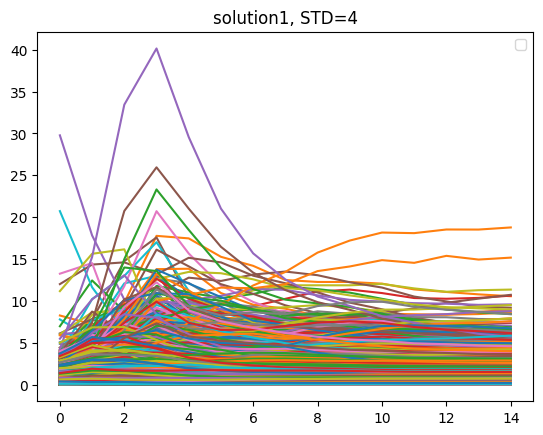

In [ ]:
plt.plot(solution1_std4)
plt.title("solution1, STD=4")
plt.show()

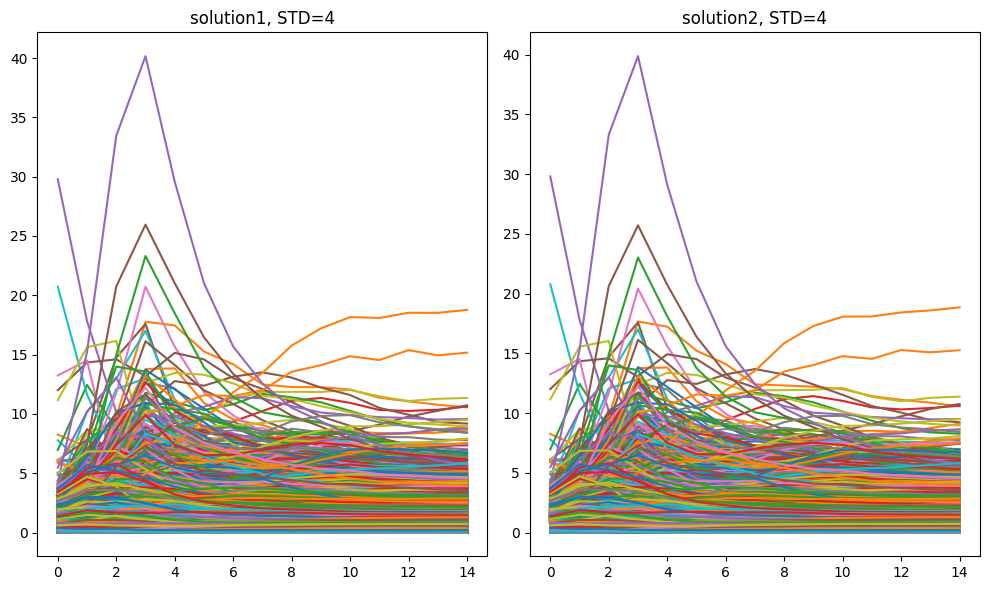

In [12]:
fig, axes = plt.subplots(1,2, figsize = (10,6))
# 1 figure with 2 axes, ie one axis per graph

axes[0].plot(solution1_std4)
axes[0].set_title("solution1, STD=4")

axes[1].plot(solution2_std4)
axes[1].set_title("solution2, STD=4")

plt.tight_layout()
plt.show()

In [13]:
def fano_factor(array, ax):
    avg = np.mean(array, axis = ax)
    var = np.var(array, axis = ax)
    return var / avg


In [14]:
fano_factor(solution1_std4, ax = 1)

array([0.37932202, 0.6047685 , 0.821471  , 0.9972809 , 0.8015535 ,
       0.6768288 , 0.62431216, 0.59600043, 0.5903678 , 0.58030677,
       0.5674926 , 0.5486287 , 0.5433269 , 0.53711396, 0.5373386 ],
      dtype=float32)

In [18]:
np.unique(fano_factor(solution1_std4, ax = 1) == fano_factor(solution2_std4, ax =1), return_counts = True)

(array([False]), array([15]))

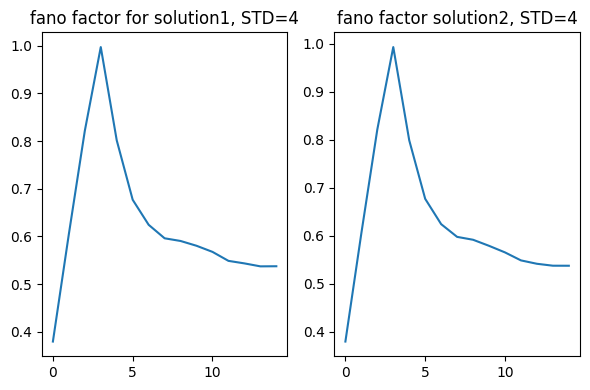

In [19]:
fig, axes = plt.subplots(1,2, figsize = (6,4))
# 1 figure with 2 axes, ie one axis per graph

axes[0].plot(fano_factor(solution1_std4, ax = 1))
axes[0].set_title("fano factor for solution1, STD=4")

axes[1].plot(fano_factor(solution2_std4, ax = 1))
axes[1].set_title("fano factor solution2, STD=4")

plt.tight_layout()
plt.show()